# Memristor Network

In [3]:
from pyontronics import EchoStateNetwork,GinfActivator, ExperimentalActivation, visualize_reservoir, BandPassNetwork, NCNM_activator
from pyontronics import MemristorNetwork

## Set up Mackey-Glass

In [9]:
import matplotlib.pyplot as plt
import numpy as np

filename = "dataPairsCondLongClipped.dat"
data = np.loadtxt(filename)     
volts = data[:, 0]                      
conds = data[:, 1]                

# Pack into a tuple
result = (volts, conds)

ginf_activator = ExperimentalActivation(data)
def mse(test, predictions):
    return np.mean((predictions - test) ** 2)

def nrmse(test, predictions):
    return np.sqrt(np.mean((predictions - test) ** 2))/(np.var(test.T[0]))

In [11]:
def MackeyGlassGenerator(tau=17, n=1000, beta=0.2, gamma=0.1, n_samples=5000, dt=1.0, seed=None):
    """
    Generate Mackey-Glass time series
    Parameters:
    tau (int): Time delay
    n (int): Number of points to generate
    beta, gamma (float): Equation parameters
    n_samples (int): Number of samples to keep
    dt (float): Time step size
    """
    if seed:
        np.random.seed(seed)

    history_len = tau * 1
    values = np.random.rand(history_len + n)

    #values[:history_len] = 1.1

    delay_steps = int(tau / dt)
    if delay_steps <= 0:
        delay_steps = 1

    for t in range(history_len, history_len + n - 1):
        x_tau = values[t - delay_steps]
        dx_dt = beta * x_tau / (1 + x_tau**10) - gamma * values[t]
        values[t + 1] = values[t] + dx_dt * dt

    return values[history_len : history_len + n_samples]

## Steady State Conductance Activator

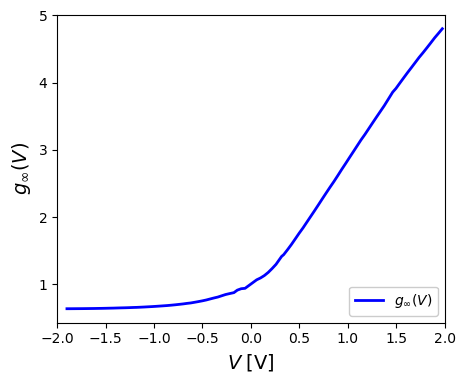

In [18]:
lookup_table = ginf_activator.get_lookup_table()

in_array = np.linspace(-2, 2, 100) 
out_array = np.tanh(in_array)+1

plt.figure(figsize=(5, 4))
plt.plot(
    lookup_table[0],
    lookup_table[1],
    label=r"$g_{\infty}(V)$",
    color="blue",
    linewidth=2,
)
plt.xlabel(r"$V \;[\text{V}]$", fontsize=14)
plt.ylabel(r"$g_{\infty}(V)$", fontsize=14)
plt.xlim(-2,2)
plt.legend(loc='lower right',framealpha=1)
#plt.savefig("output/ginf_activator_plot.pdf",bbox_inches='tight')
#plt.savefig("output/ginf_activator_plot.png",bbox_inches='tight')

In [20]:
# Generate Mackey-Glass time series for train and test sets
mg_dt = 0.1
n_MG = 10000
mg_series = MackeyGlassGenerator(tau=17, n=n_MG, n_samples=n_MG, dt=mg_dt, seed=42)
mg_series_test = MackeyGlassGenerator(tau=17, n=n_MG*10, n_samples=n_MG*10, dt=mg_dt, seed=24)
mg_time = np.arange(len(mg_series)) * mg_dt
mg_time_test = np.arange(len(mg_series_test)) * mg_dt

# Normalize data
totalAmp = 2
minPoint = 0
mg_series = totalAmp * (mg_series - mg_series.min()) / (mg_series.max() - mg_series.min()) - minPoint
mg_series_test = totalAmp * (mg_series_test - mg_series_test.min()) / (mg_series_test.max() - mg_series_test.min()) - minPoint

# Create input/output pairs for time series prediction
inputs = mg_series[:-1].reshape(-1, 1)
targets = mg_series[1:].reshape(-1, 1)

inputs_test = mg_series_test[:-1].reshape(-1, 1)
targets_test = mg_series_test[1:].reshape(-1, 1)

# Prepare train and test sets of desired lengths
train_len = 50000
test_len = 100000
train_inputs = inputs[:train_len]
train_targets = targets[:train_len]
test_inputs = inputs_test[:test_len]
test_targets = targets_test[:test_len]

# Calculate variance of test data
test_var = np.var(train_targets)

## MG with large voltage network

In [27]:
# Create a simple 4-vertex, 4-edge network
timestep = mg_dt

network_16 = MemristorNetwork(num_vertices=9, num_edges=15, ground_vertices=[8], dt=timestep, activation=ginf_activator.activate)

# Set connectivity: edges between vertices
# Format: (vertex_i, vertex_j, edge_index)
edges = [
    (0, 1, 0), 
    (0, 4, 1),
    (6, 0, 2),
    (0, 7, 3),
    (7, 6, 4),
    (6, 8, 5),  
    (8, 7, 6),
    (8, 4, 7),
    (5, 8, 8),
    (4, 5, 9),
    (4, 2, 10),
    (2, 3, 11),
    (2, 5, 12),
    (3, 5, 13),
    (1, 4, 14)
]
network_16.set_connectivity(edges)

# Set custom memristor parameters
g0_values = np.full(15,1.0)    # Equilibrium conductances
tau_values = np.arange(1,1+0.5*15,0.5)   # Different timescales

# Orientations are set automatically based on connectivity

network_16.set_memristor_parameters(
    g0_values=g0_values,
    tau_values=tau_values
)

# Set which vertex has imposed voltage
imposed_vertices = [0,2]  # Change this to any vertex you want
network_16.set_imposed_voltage_vertices(imposed_vertices)

# Define imposed voltage function (sinusoidal input)
def voltage_input(time):
        # Use interpolation to get MG value at exact time
        return {imposed_vertices[0]: np.interp(time, mg_time, mg_series),
                imposed_vertices[1]: np.interp(time, mg_time, -mg_series)}

network_16.set_imposed_voltages(voltage_input)

# Run simulation
time_points, voltages, currents, conductances, powers = network_16.simulate(
    total_time=200,
    save_interval=timestep,
    
)

print(f"Simulation completed with {len(time_points)} time points")

Simulation completed with 2000 time points


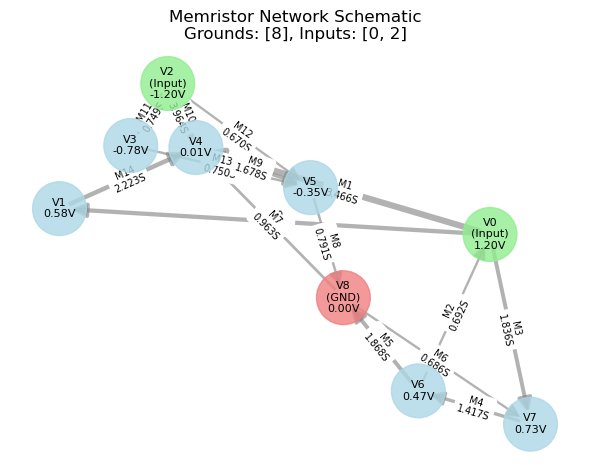

In [29]:
# Final state schematic
fig_network_16 = network_16.plot_network_schematic(
    current_voltages=voltages[-1],
    current_conductances=conductances[-1],
    input_seed = 4
)
#fig2.suptitle(f"Final Network State (t={time_points[-1]:.1f}s)", fontsize=14)
plt.show()

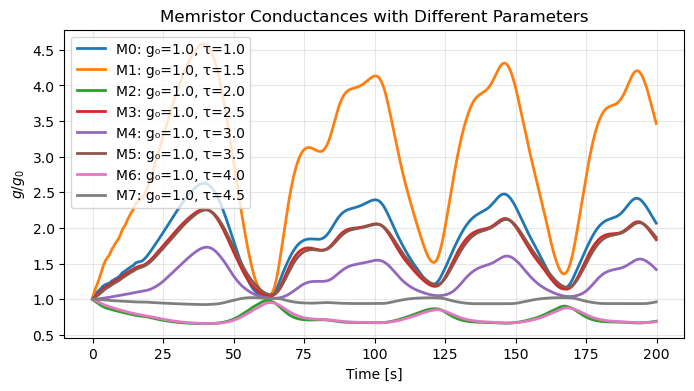

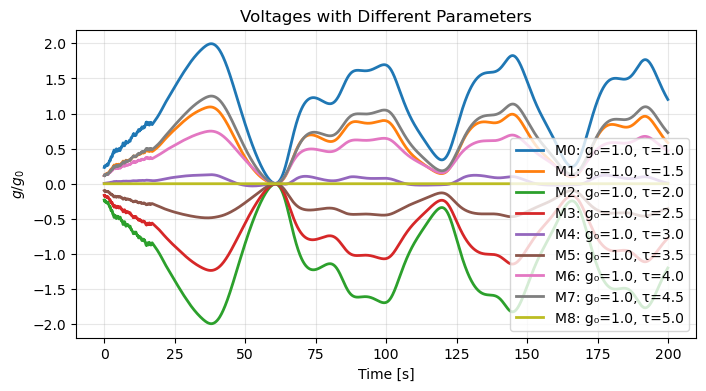

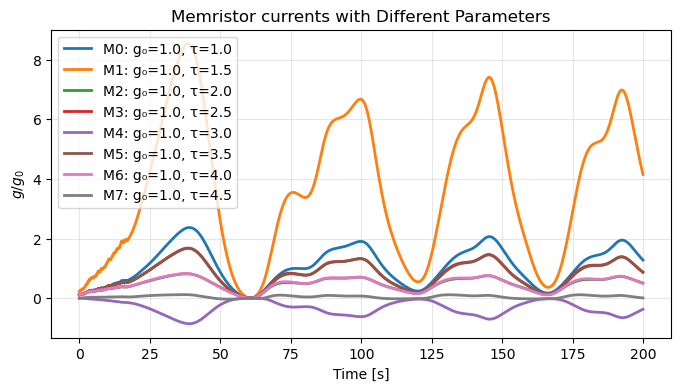

In [31]:
# Plot memristor conductances and voltages with different parameters
plt.figure(figsize=(8, 4))
#for i in range(network_16.num_edges):
for i in range(8):
    plt.plot(time_points, conductances[:, i]/g0_values[i], 
            label=f'M{i}: g₀={network_16.g0[i]:.1f}, τ={network_16.tau[i]:.1f}',
            linewidth=2)

plt.xlabel('Time [s]')
plt.ylabel('$g/g_{0}$')
plt.title('Memristor Conductances with Different Parameters')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
for i in range(network_16.num_vertices):
    plt.plot(time_points, voltages[:, i]/g0_values[i], 
            label=f'M{i}: g₀={network_16.g0[i]:.1f}, τ={network_16.tau[i]:.1f}',
            linewidth=2)

plt.xlabel('Time [s]')
plt.ylabel('$g/g_{0}$')
plt.title('Voltages with Different Parameters')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
for i in range(8):
    plt.plot(time_points, currents[:, i]/g0_values[i], 
            label=f'M{i}: g₀={network_16.g0[i]:.1f}, τ={network_16.tau[i]:.1f}',
            linewidth=2)

plt.xlabel('Time [s]')
plt.ylabel('$g/g_{0}$')
plt.title('Memristor currents with Different Parameters')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [33]:
# Set prediction parameters
network_16.set_prediction_parameters(
    use_conductances = False,    # Use memristor voltages as features
    prediction_window = 10,     # Predict 10 steps ahead (1 ms with dt=0.1 ms)
    regularization = 1e-4
)

# Generate training data
t_train = mg_time
input_signal = mg_series

# Target: input signal shifted by prediction window
target_signal = np.roll(input_signal, -network_16.prediction_window)
target_signal[-network_16.prediction_window:] = 0  # Set end to zero

# Train output weights
W_out = network_16.train_output(total_time=1000.0)
print(f"Trained output weights: {W_out}")

# Generate test data
predict_steps = 50000

t_test = mg_time_test[0:predict_steps]
test_input = mg_series_test[0:predict_steps]
test_target = np.roll(test_input, -network_16.prediction_window)
test_target[-network_16.prediction_window:] = 0

Trained output weights: [  9.61027696 -10.21927237 -10.43808895  11.22159167   0.4283678
 -11.74981016  -0.021834  ]


In [34]:
# Define imposed test voltage function
def voltage_input(time):
        # Use interpolation to get MG value at exact time
        return {imposed_vertices[0]: np.interp(time, mg_time_test, mg_series_test),
                imposed_vertices[1]: np.interp(time, mg_time_test, -mg_series_test)}

network_16.set_imposed_voltages(voltage_input)

# Make predictions
predictions, time_points, powers = network_16.predict(total_time=predict_steps*timestep)

# Evaluate
mse, rmse, nrmse, power, energy = network_16.evaluate_prediction(predictions,test_target,t_test,powers,time_window=(1000.0, 5000.0))
print(f"MSE: {mse:.6f}, RMSE: {rmse:.6f}, NRMSE: {nrmse:.6f}")

MSE: 0.000857, RMSE: 0.029282, NRMSE: 0.059066


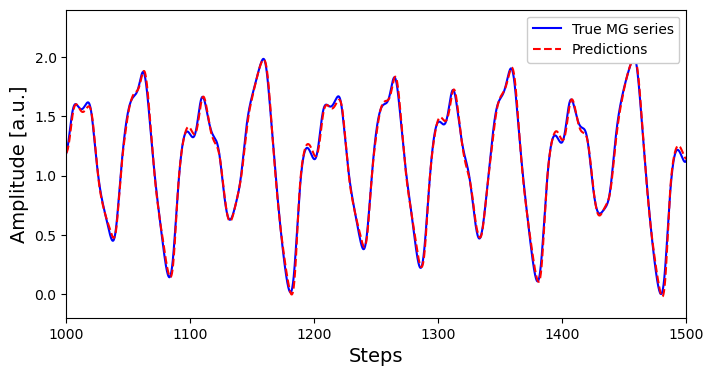

In [36]:
# Plot results
plt.figure(figsize=(8, 4))
#plt.plot(t_test, test_input, label='Input signal', alpha=0.7)
plt.plot(t_test, test_target, label="True MG series", alpha=1, color='blue')
plt.plot(t_test, predictions, label="Predictions", linestyle="--", alpha=1, color='red')
plt.xlim(1000.0,1500.0)
plt.ylim(-0.2,2.4)
plt.xlabel("Steps", fontsize=14)
plt.ylabel("Amplitude [a.u.]", fontsize=14)
#plt.title(f'Memristor Network Prediction ({network_16.prediction_window} = {network_16.prediction_window*timestep} s steps ahead)')
plt.legend(loc='upper right',framealpha=1)
#plt.grid(True, alpha=0.3)
#plt.show()
#plt.savefig("output/mg_prediction_plot.pdf",bbox_inches='tight')

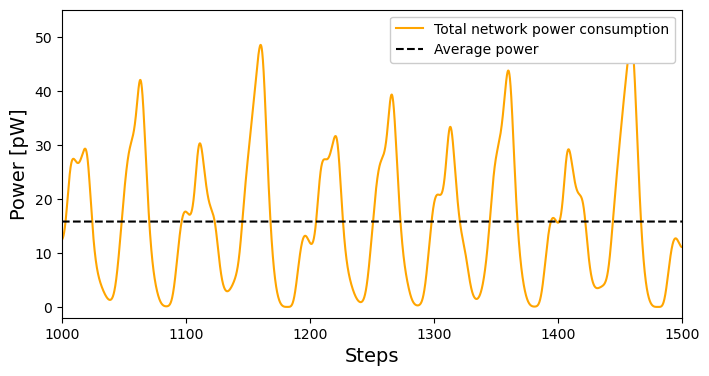

In [37]:
# Plot results
plt.figure(figsize=(8, 4))
#plt.plot(t_test, test_input, label='Input signal', alpha=0.7)
plt.plot(t_test, power, label="Total network power consumption", alpha=1, color='orange')
plt.plot(t_test, np.mean(power)*np.ones(len(power)), label="Average power", linestyle="--", alpha=1, color='black')
plt.xlim(1000,1500)
plt.ylim(-2,55)
plt.xlabel("Steps", fontsize=14)
plt.ylabel("Power [pW]", fontsize=14)
#plt.title(f'Memristor Network Prediction ({network_16.prediction_window} = {network_16.prediction_window*timestep} s steps ahead)')
plt.legend(loc='upper right',framealpha=1)
#plt.grid(True, alpha=0.3)
#plt.show()
plt.savefig("output/powers.pdf",bbox_inches='tight')

In [38]:
# Average power consumption (pW)
print(np.mean(power))

15.798745550787046
